#### Milestone 1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['column', 'missing_count']


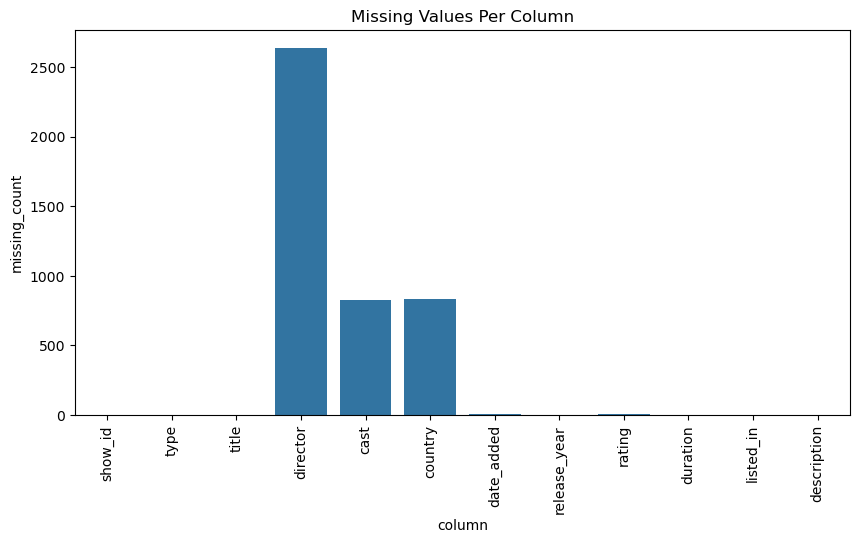

In [7]:

plt.figure(figsize=(10,5))
sns.barplot(data=missing_df, x='column', y='missing_count')
plt.xticks(rotation=90)
plt.title("Missing Values Per Column")
plt.show()


In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('No Data')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])


In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [11]:
df = df.dropna(subset=['date_added'])

In [12]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


In [13]:
df['date_added'].dtype

dtype('<M8[ns]')

In [14]:
df[df.duplicated()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added


In [15]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

In [16]:
df.to_csv("cleaned_netflix_data.csv", index=False)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No Data,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,No Data,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


#### Milestone 2 

In [17]:
data = pd.read_csv("cleaned_netflix_data.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No Data,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,No Data,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


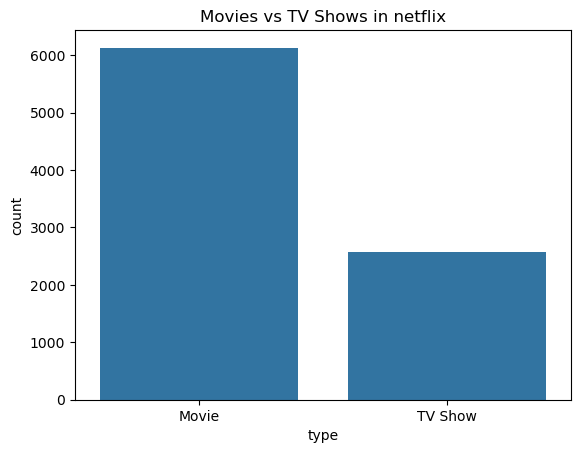

<Figure size 1200x600 with 0 Axes>

In [18]:
sns.countplot(data=data , x = 'type')
plt.title("Movies vs TV Shows in netflix")
plt.figure(figsize = (12,6))
plt.show()

In [19]:
'''
Observation:
Movies dominate the platform compared to TV Shows.

Explanation:
Netflix content is heavily movie-focused. TV Shows are growing but still significantly
fewer than movies.'''

'\nObservation:\nMovies dominate the platform compared to TV Shows.\n\nExplanation:\nNetflix content is heavily movie-focused. TV Shows are growing but still significantly\nfewer than movies.'

In [20]:
data['rating'].value_counts()

rating
TV-MA       3187
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [21]:
'''TV-MA
Mature Audience Only.
Suitable for adults. May contain strong language, violence, or sexual content.

TV-14
Parents strongly cautioned.
May not be suitable for children under 14.

TV-PG
Parental guidance suggested.
Some material may not be suitable for younger children.

TV-Y7
Directed to children age 7 and above.
May include mild fantasy violence.

TV-Y
Suitable for all children.

TV-G
General audience. Suitable for all ages.

TV-Y7-FV
TV-Y7 with fantasy violence.

R
Restricted.
Under 17 requires accompanying parent or adult guardian.

PG-13
Parents strongly cautioned.
Some material may be inappropriate for children under 13.

PG
Parental guidance suggested.

G
General audience. Suitable for all ages.

NC-17
No one 17 and under admitted.
Adults only.

NR
Not Rated.
No official rating assigned.

UR
Unrated version.
Typically contains additional or unreviewed content.'''

'TV-MA\nMature Audience Only.\nSuitable for adults. May contain strong language, violence, or sexual content.\n\nTV-14\nParents strongly cautioned.\nMay not be suitable for children under 14.\n\nTV-PG\nParental guidance suggested.\nSome material may not be suitable for younger children.\n\nTV-Y7\nDirected to children age 7 and above.\nMay include mild fantasy violence.\n\nTV-Y\nSuitable for all children.\n\nTV-G\nGeneral audience. Suitable for all ages.\n\nTV-Y7-FV\nTV-Y7 with fantasy violence.\n\nR\nRestricted.\nUnder 17 requires accompanying parent or adult guardian.\n\nPG-13\nParents strongly cautioned.\nSome material may be inappropriate for children under 13.\n\nPG\nParental guidance suggested.\n\nG\nGeneral audience. Suitable for all ages.\n\nNC-17\nNo one 17 and under admitted.\nAdults only.\n\nNR\nNot Rated.\nNo official rating assigned.\n\nUR\nUnrated version.\nTypically contains additional or unreviewed content.'

In [22]:
data = data[~data['rating'].str.contains('min', na = False)]


In [23]:
data['rating'].value_counts()
#removed 74 min,84 min,66 min because they are not ratings. they are duration.
#even those are only 3 values so if we remove them it will not affect our analysis much.

rating
TV-MA       3187
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

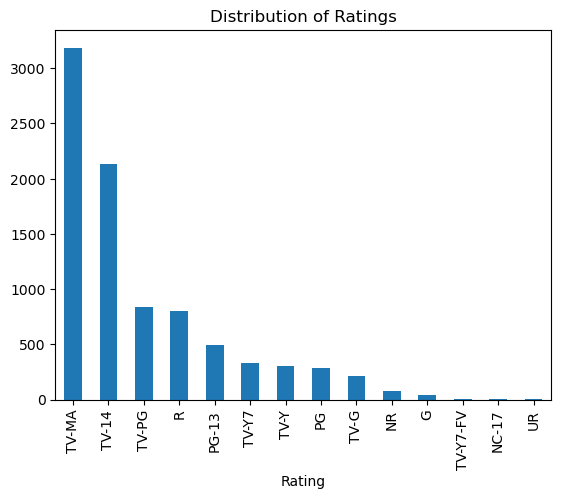

In [24]:
data['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.show()

In [25]:
'''
Observation: 
TV-MA and TV-14 ratings dominate the dataset .'''

'\nObservation: \nTV-MA and TV-14 ratings dominate the dataset .'

In [26]:

data['decade'] = (data['release_year'] // 10) * 10
data['decade'].value_counts().sort_index()

decade
1920       1
1940      15
1950      11
1960      24
1970      69
1980     128
1990     271
2000     804
2010    5838
2020    1545
Name: count, dtype: int64

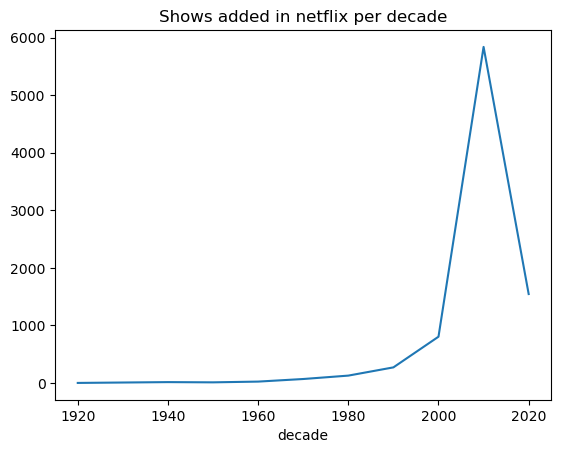

In [27]:
data['decade'].value_counts().sort_index().plot(kind='line')
plt.title("Shows added in netflix per decade")
plt.xlabel("decade")
plt.show()

In [28]:
'''observation:
Movies and shows(More no.of content) show sharp growth in the 2010s.'''

'observation:\nMovies and shows(More no.of content) show sharp growth in the 2010s.'

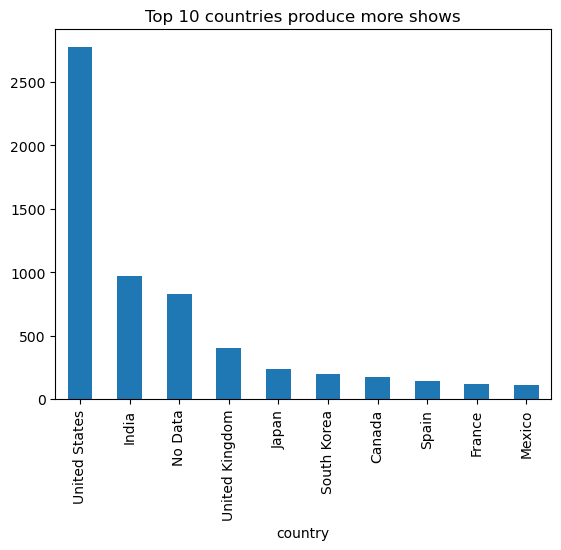

In [29]:
data['country'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 countries produce more shows")
plt.show()

Text(0.5, 1.0, "Top 10 countries wthout 'No Data'")

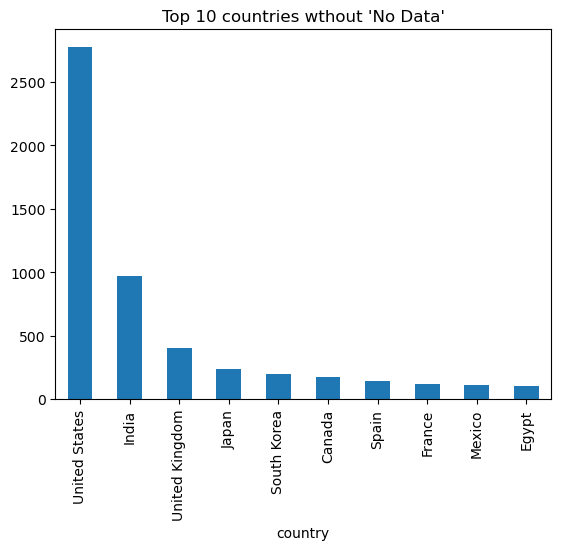

In [30]:
data[data['country'] != 'No Data']['country'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 countries wthout 'No Data'")

In [31]:
'''Observation:
United States produces the highest number of titles, followed by India and the United Kingdom.

Explanation:
The US is the dominant content contributor on Netflix. 
India is the second-largest contributor, indicating strong regional expansion 
and localization strategy.'''

'Observation:\nUnited States produces the highest number of titles, followed by India and the United Kingdom.\n\nExplanation:\nThe US is the dominant content contributor on Netflix. \nIndia is the second-largest contributor, indicating strong regional expansion \nand localization strategy.'

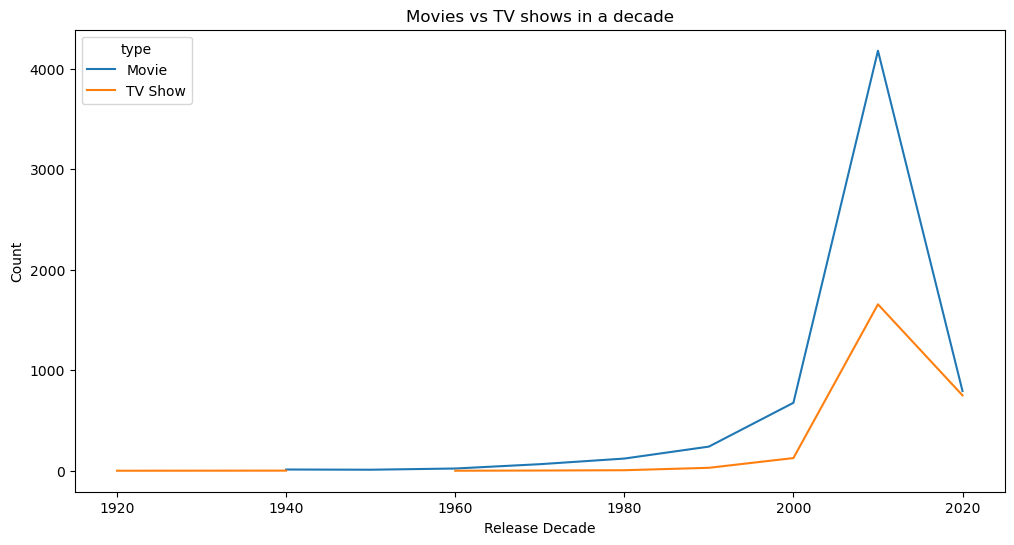

In [32]:
year_type = data.groupby(['decade', 'type']).size().unstack()
year_type.plot(figsize=(12,6))
plt.title("Movies vs TV shows in a decade")
plt.ylabel("Count")
plt.xlabel("Release Decade")
plt.show()

In [33]:
'''
Observation:
Content volume increased sharply after 2000, especially during the 2010s. 
Movies consistently outnumber TV Shows across all decades.

Explanation:
The 2010s mark the rapid expansion phase of Netflix. 
The growth spike reflects platform scaling rather than a genre or type shift.
'''

'\nObservation:\nContent volume increased sharply after 2000, especially during the 2010s. \nMovies consistently outnumber TV Shows across all decades.\n\nExplanation:\nThe 2010s mark the rapid expansion phase of Netflix. \nThe growth spike reflects platform scaling rather than a genre or type shift.\n'

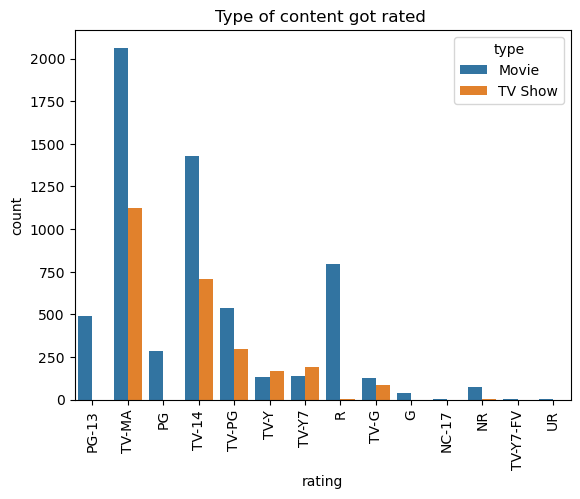

In [34]:
sns.countplot(data=data, x='rating', hue = 'type')
plt.title("Type of content got rated ")
plt.xticks(rotation = 90)
plt.show()

In [35]:
'''
Observation:
TV-MA and TV-14 ratings dominate the dataset.
Explanation:
Most Netflix content targets mature and young adult audiences.
 Family and kids categories exist but represent a smaller portion of total content.'''

'\nObservation:\nTV-MA and TV-14 ratings dominate the dataset.\nExplanation:\nMost Netflix content targets mature and young adult audiences.\n Family and kids categories exist but represent a smaller portion of total content.'

In [36]:
data_analyse = data.copy()
data_analyse['genre'] = data_analyse['listed_in'].str.split(',')
data_analyse = data_analyse.explode('genre')
data_analyse['genre'] = data_analyse['genre'].str.strip()

genre_type = pd.crosstab(data_analyse['genre'],data_analyse['type'])

top_genre = data_analyse['genre'].value_counts().head(20).index

genre_type.loc[top_genre]

type,Movie,TV Show
genre,,
International Movies,2752,0
Dramas,2427,0
Comedies,1674,0
International TV Shows,0,1328
Documentaries,869,0
Action & Adventure,859,0
Independent Movies,756,0
TV Dramas,0,739
Children & Family Movies,641,0


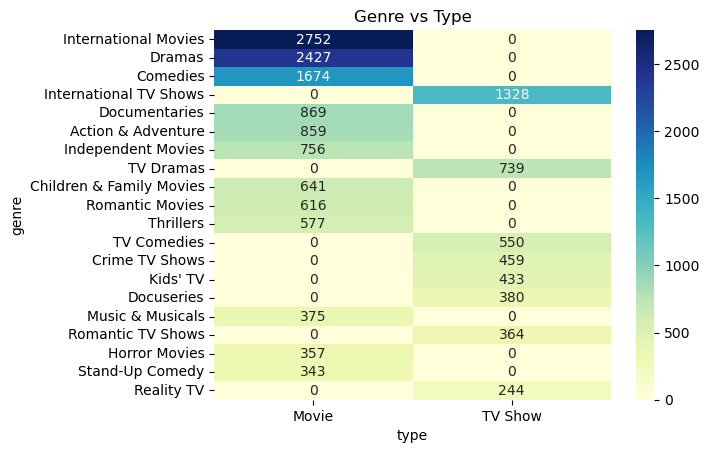

In [37]:
top_20 = data_analyse['genre'].value_counts().head(20).index
sns.heatmap(genre_type.loc[top_20], annot=True, fmt='d', cmap='YlGnBu')
plt.title("Genre vs Type")
plt.show()

In [38]:
''''
Observation:
International Movies, Dramas, and Comedies dominate Movies.
International TV Shows and TV Dramas dominate TV Shows.

Explanation:
Movie content is diversified but strongly centered around drama and international categories.
TV Shows lean heavily toward serialized drama and international formats.'''

"'\nObservation:\nInternational Movies, Dramas, and Comedies dominate Movies.\nInternational TV Shows and TV Dramas dominate TV Shows.\n\nExplanation:\nMovie content is diversified but strongly centered around drama and international categories.\nTV Shows lean heavily toward serialized drama and international formats."

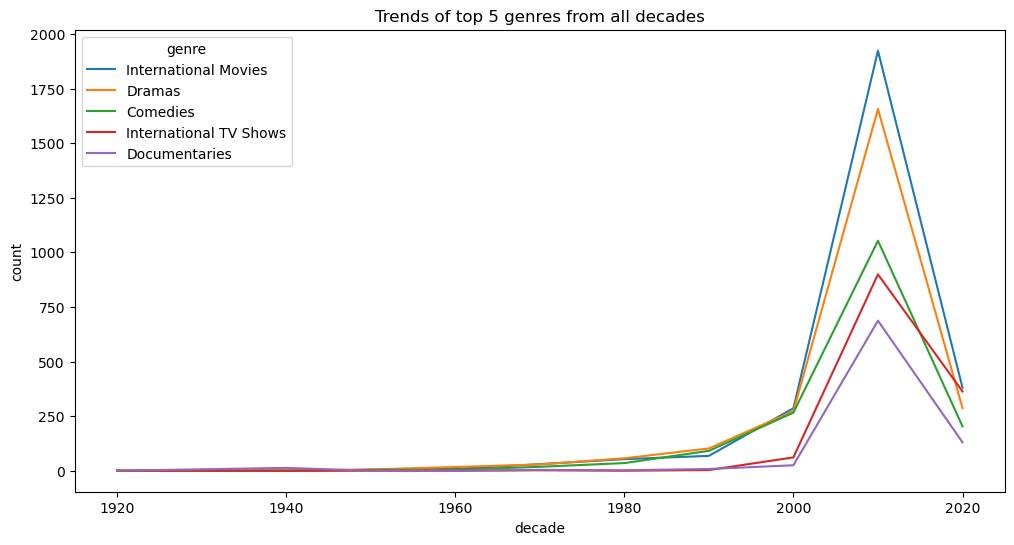

In [39]:
data_analyse['decade'] = (data_analyse['release_year'] // 10) * 10
genre_year = pd.crosstab(data_analyse['decade'],data_analyse['genre'])
top_5 = data_analyse['genre'].value_counts().head(5).index
genre_year[top_5].plot(figsize=(12,6))
plt.title("Trends of top 5 genres from all decades")
plt.xlabel('decade')
plt.xticks(rotation = 0)
plt.ylabel('count')
plt.show()

In [40]:
'''Observation:
All top genres show sharp growth in the 2010s.

Explanation:
The rise reflects overall content expansion rather than a sudden change in audience interest. 
Platform growth drives genre volume increase'''

'Observation:\nAll top genres show sharp growth in the 2010s.\n\nExplanation:\nThe rise reflects overall content expansion rather than a sudden change in audience interest. \nPlatform growth drives genre volume increase'

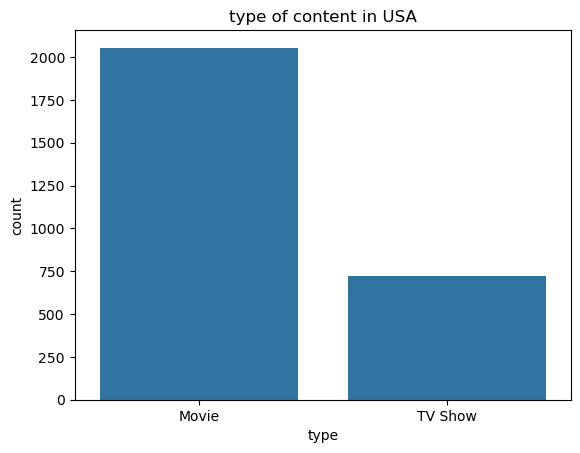

In [41]:
sns.countplot(data=data[data['country'] == 'United States'], x='type')
plt.title("type of content in USA")
plt.xticks(rotation = 0)
plt.show()

In [42]:
usa = data[data['country'] == 'United States']
usa_genre = usa['listed_in'].str.split(',').explode().str.strip()
usa_Gcount = usa_genre.value_counts()
usa_Gcount.head(10)

listed_in
Dramas                      591
Comedies                    524
Documentaries               411
Independent Movies          302
Children & Family Movies    272
Action & Adventure          249
TV Comedies                 217
Stand-Up Comedy             215
Thrillers                   193
TV Dramas                   175
Name: count, dtype: int64

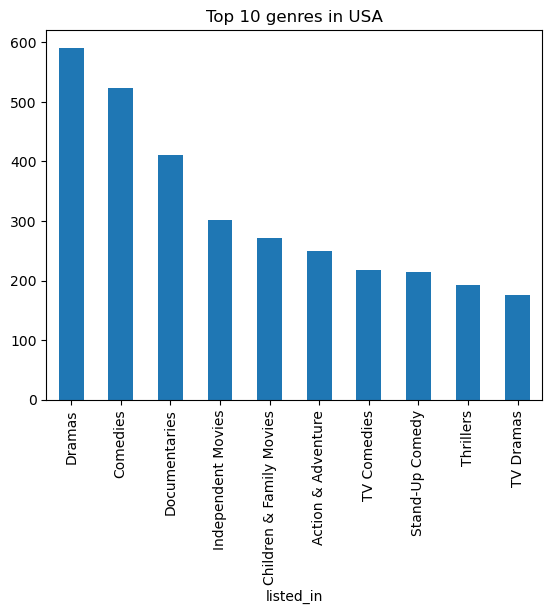

In [43]:
usa_Gcount.head(10).plot(kind='bar')
plt.title("Top 10 genres in USA")
plt.show()

In [44]:
'''Observation:
Dramas, Comedies, and Documentaries are the top genres in the United States.

Explanation:
US content emphasizes narrative-driven and entertainment-focused categories, 
with strong representation in documentary and independent films.'''

'Observation:\nDramas, Comedies, and Documentaries are the top genres in the United States.\n\nExplanation:\nUS content emphasizes narrative-driven and entertainment-focused categories, \nwith strong representation in documentary and independent films.'

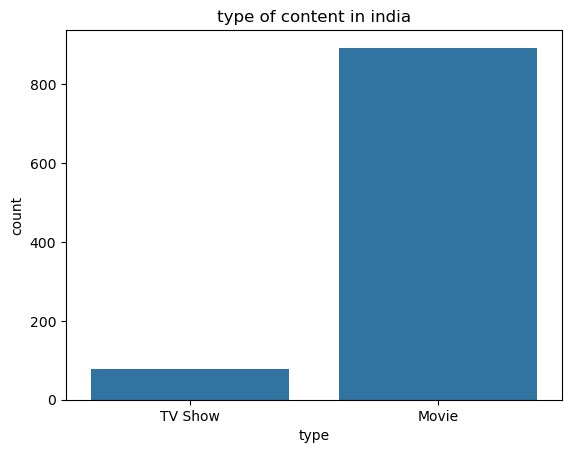

In [45]:
sns.countplot(data=data[data['country'] == 'India'], x='type')
plt.title("type of content in india")
plt.xticks(rotation = 0)
plt.show()

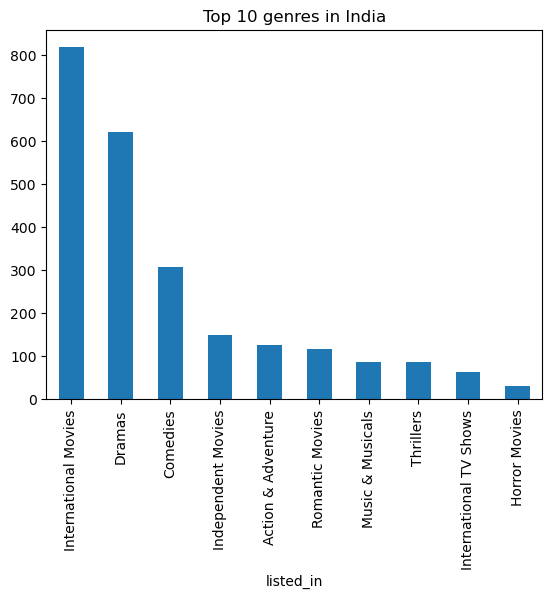

In [46]:
india = data[data['country'] == 'India']
india_genre = india['listed_in'].str.split(',').explode().str.strip()
india_Gcount = india_genre.value_counts().head(10)
india_Gcount.plot(kind='bar')
plt.title("Top 10 genres in India")
plt.show()

In [47]:
'''Observation:
International Movies and Dramas dominate Indian-listed content.

Explanation:
Netflix offers a strong presence of drama and internationally categorized films in India. 
'''

'Observation:\nInternational Movies and Dramas dominate Indian-listed content.\n\nExplanation:\nNetflix offers a strong presence of drama and internationally categorized films in India. \n'

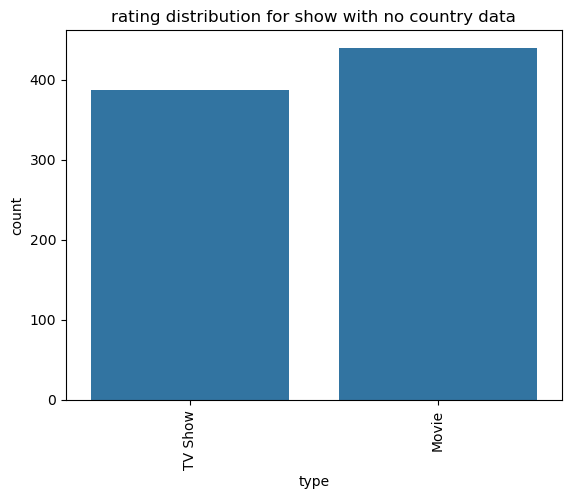

In [48]:
sns.countplot(data=data[data['country'] == 'No Data'], x='type')
plt.title("rating distribution for show with no country data")
plt.xticks(rotation = 90)
plt.show()

In [49]:
'''Observation:
No Country data covers mostly Movies content rather than Tv Shows.
'''

'Observation:\nNo Country data covers mostly Movies content rather than Tv Shows.\n'

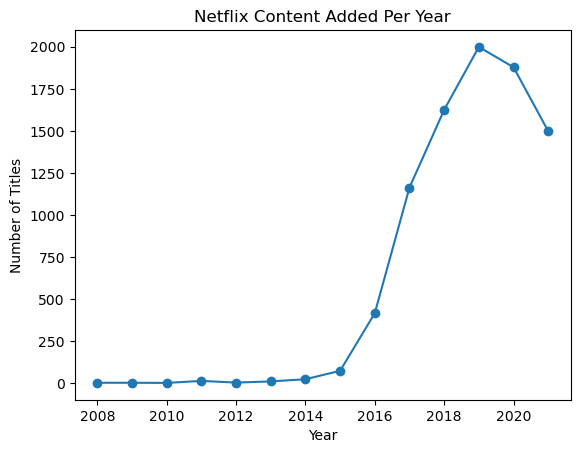

In [50]:
data['date_added'] = pd.to_datetime(data['date_added'])
data['year_added'] = data['date_added'].dt.year

content_growth = data['year_added'].value_counts().sort_index()

content_growth.plot(kind='line', marker='o')
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [51]:
'''observation : Netflix content expansion accelerated after 2015.'''

'observation : Netflix content expansion accelerated after 2015.'

In [52]:
movies = data[data['type']=='Movie'].copy()
movies['duration_int'] = movies['duration'].str.replace(' min','').astype(int)

In [53]:
def length_category(x):
    if x < 60:
        return "Short"
    elif x <= 120:
        return "Medium"
    else:
        return "Long"

movies['length_category'] = movies['duration_int'].apply(length_category)

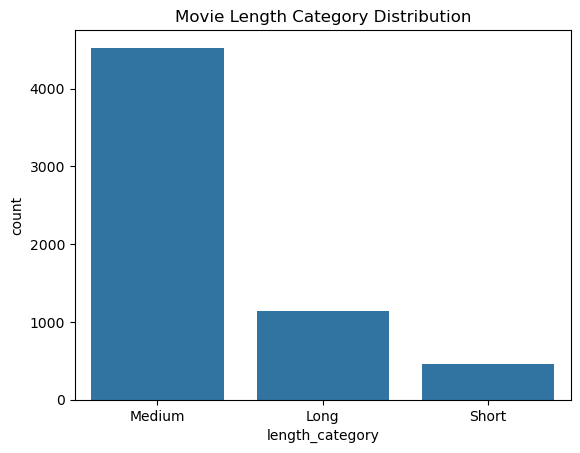

In [54]:
sns.countplot(data=movies, x='length_category')
plt.title("Movie Length Category Distribution")
plt.show()

In [55]:
'''observation: Most Netflix movies fall in medium duration (60–120 minutes).'''

'observation: Most Netflix movies fall in medium duration (60–120 minutes).'

In [56]:
tv = data[data['type']=='TV Show'].copy()

tv['seasons'] = tv['duration'].str.replace(' Seasons','').str.replace(' Season','')
tv['seasons'] = tv['seasons'].astype(int)

In [57]:
def season_category(x):
    if x == 1:
        return "Single Season"
    elif x <= 3:
        return "Limited Series"
    else:
        return "Multi-season"

tv['season_category'] = tv['seasons'].apply(season_category)
print(tv['season_category'].value_counts())

season_category
Single Season     1791
Limited Series     562
Multi-season       225
Name: count, dtype: int64


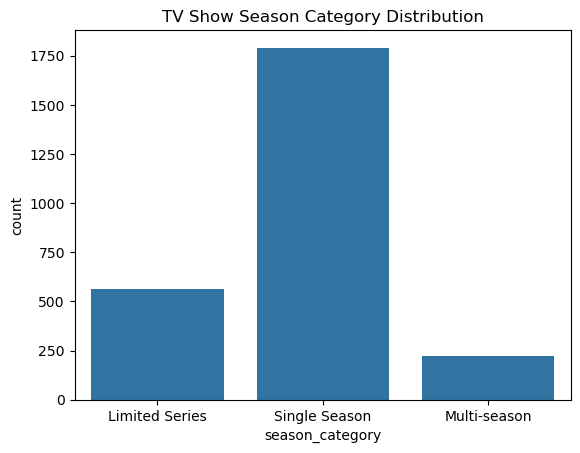

In [58]:
sns.countplot(data=tv, x='season_category')
plt.title("TV Show Season Category Distribution")
plt.show()

In [59]:
data['is_original'] = data['director'].apply(lambda x: "Likely Licensed" if x=="Unknown" else "Likely Original")
print(data['is_original'].value_counts())

is_original
Likely Original    6165
Likely Licensed    2541
Name: count, dtype: int64


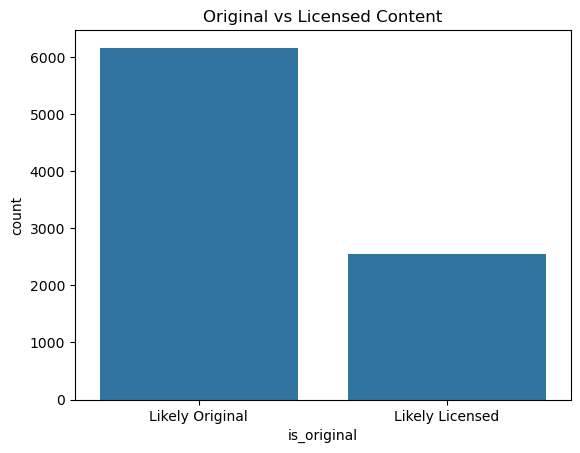

In [60]:
sns.countplot(data=data, x='is_original')
plt.title("Original vs Licensed Content")
plt.show()


#### Milestone 3

In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data_model = data.copy()
data_model['type_enc'] = le.fit_transform(data_model['type'])
data_model['rating_enc'] = le.fit_transform(data_model['rating'])

In [62]:
data_model['genre_count'] = data_model['listed_in'].apply(lambda x: len(str(x).split(',')))
#Counts how many genres each title has.

In [63]:
data_model['duration_num'] = data_model['duration'].str.extract(r'(\d+)').astype(float)
#Extracts the number from the duration column to get a numeric value for duration so model can use it.

In [64]:
from datetime import datetime
current_year = datetime.now().year
data_model['content_age'] = current_year - data_model['release_year']

In [65]:
from sklearn.cluster import KMeans
cluster_features = data_model[['rating_enc','duration_num','genre_count','content_age']].dropna()
kmeans = KMeans(n_clusters=4, random_state=42)
data_model.loc[cluster_features.index, 'cluster'] = kmeans.fit_predict(cluster_features)

In [66]:
data_model.groupby('cluster')[['duration_num','genre_count','content_age']].mean()

,duration_num,genre_count,content_age
cluster,,,
0.0,66.894973,1.585278,11.203770
1.0,2.934799,2.252747,9.306227
2.0,139.434856,2.555838,17.007614
3.0,99.787228,2.222826,12.164674


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = data_model[['rating_enc','duration_num','genre_count','content_age']]
y = data_model['type_enc']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)
import joblib
joblib.dump(model, "netflix_content_classifier.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

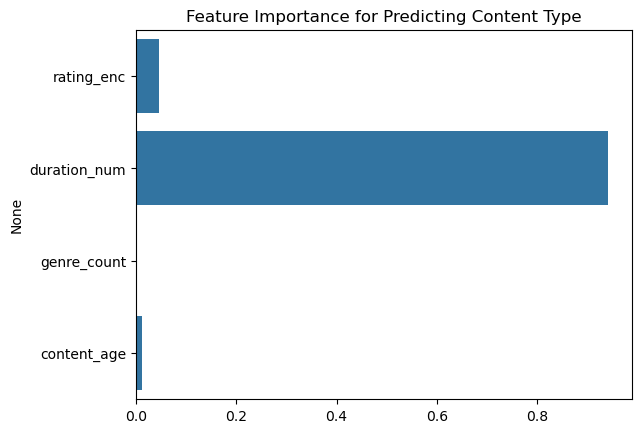

In [68]:
importance = pd.Series(model.feature_importances_, index=X.columns)
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance for Predicting Content Type")
plt.show()

In [69]:
from sklearn.metrics import accuracy_score
pred = model.predict(X_test)
accuracy_score(y_test,pred)

0.9971297359357061

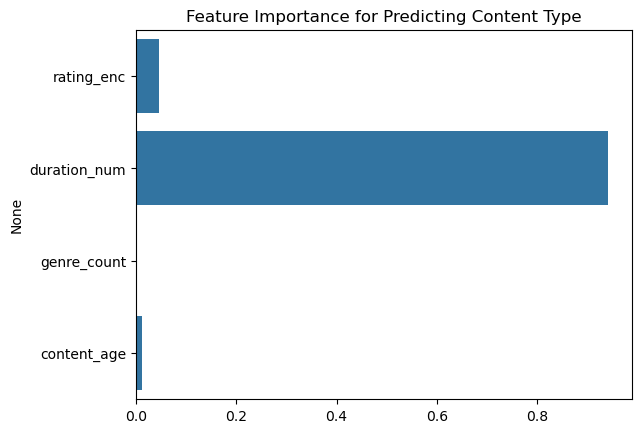

In [70]:
importance = pd.Series(model.feature_importances_, index=X.columns)
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance for Predicting Content Type")
plt.show()

In [71]:
data_model.groupby('cluster')['release_year'].mean()

cluster
0.0    2014.796230
1.0    2016.693773
2.0    2008.992386
3.0    2013.835326
Name: release_year, dtype: float64

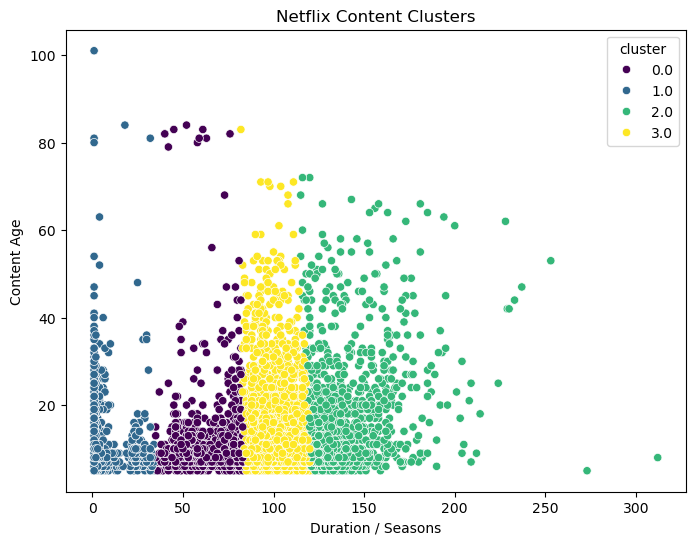

In [72]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data_model,
    x="duration_num",
    y="content_age",
    hue="cluster",
    palette="viridis"
)

plt.title("Netflix Content Clusters")
plt.xlabel("Duration / Seasons")
plt.ylabel("Content Age")
plt.show()

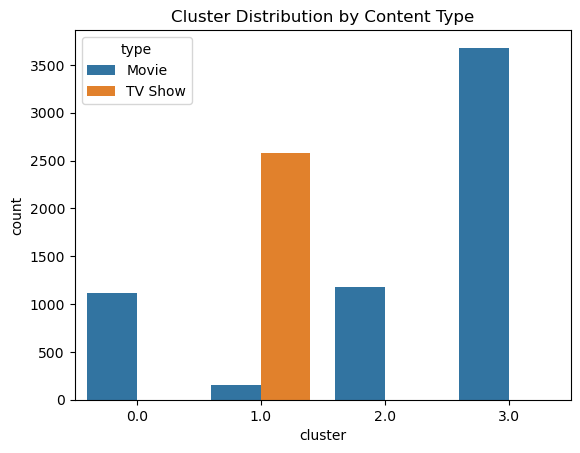

In [73]:
sns.countplot(data=data_model, x="cluster", hue="type")
plt.title("Cluster Distribution by Content Type")
plt.show()

In [74]:
model = joblib.load("netflix_content_classifier.pkl")